In [2]:
from datetime import datetime
import geopandas as gpd
##from functions.funcs import *
from datetime import datetime, timedelta
import pandas as pd 
import shapely as sp 
from functions.funcs import *
import xarray as xr
from scipy.interpolate import interpn 


In [45]:

data = gpd.read_file(r"Palmyra Data\MI_and_SAT_FAD_positions")
data = samplefreq(data)
data, delx_list, dely_list  = add_distance_collumns(data)
data = add_time_collumns(data)
print(data.columns)


c:\FATE\functions\funcs.py:173: RuntimeWarning: divide by zero encountered in divide
  heading = np.atan(delx_long/dely_long)


Index(['Shape_Leng', 'Set_3', 'BuoyName', 'Name_ID', 'MinOfTimes',
       'MaxOfTimes', 'MinOfDate', 'MaxOfDate', 'Yr_min', 'Mon_min', 'Day_min',
       'Yr_max', 'Mon_max', 'Day_max', 'Diff_days', 'Distance_n', 'geometry',
       'numpoints', 'SampleFreq', 'x_deg', 'y_deg', 'x_km', 'y_km', 'xy_km',
       'timelist'],
      dtype='object')


In [4]:
ds = xr.open_dataset(r"C:\FATE\Data\cmems(3).nc")
vo  = ds['vo'] ## this is y velocity
uo = ds['uo'] ## this is x velocity
print(ds)

<xarray.Dataset> Size: 436MB
Dimensions:    (time: 1156, depth: 15, latitude: 40, longitude: 38)
Coordinates:
  * depth      (depth) float32 60B 0.494 1.541 2.646 3.819 ... 21.6 25.21 29.44
  * latitude   (latitude) float32 160B 4.5 4.583 4.667 4.75 ... 7.583 7.667 7.75
  * longitude  (longitude) float32 152B -163.8 -163.7 -163.6 ... -160.8 -160.7
  * time       (time) datetime64[ns] 9kB 2021-07-01 2021-07-02 ... 2024-08-29
Data variables:
    uo         (time, depth, latitude, longitude) float64 211MB ...
    vo         (time, depth, latitude, longitude) float64 211MB ...
    zos        (time, latitude, longitude) float64 14MB ...
Attributes:
    copernicusmarine_version:  2.2.2


In [5]:
## Grabbing one time, and GPS cord from data to search for in cmens dataset
time  = data.at[1,"timelist"][0]
startpoint = sp.get_point(data.at[1,"geometry"],0)
lat = startpoint.y
lon = startpoint.x
print(time, startpoint, lat, lon )

2024-04-07 12:54:59.996159691 POINT (-160.98606999999998 7.727930000000072) 7.727930000000072 -160.98606999999998


In [6]:
vo.time

<xarray.DataArray 'time' (time: 1156)> Size: 9kB
array(['2021-07-01T00:00:00.000000000', '2021-07-02T00:00:00.000000000',
       '2021-07-03T00:00:00.000000000', ..., '2024-08-27T00:00:00.000000000',
       '2024-08-28T00:00:00.000000000', '2024-08-29T00:00:00.000000000'],
      shape=(1156,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 9kB 2021-07-01 2021-07-02 ... 2024-08-29
Attributes:
    standard_name:  time
    long_name:      Time
    axis:           T
    unit_long:      Hours Since 1950-01-01

In [7]:
nearest = vo.sel(latitude = lat, longitude = lon, depth = 1,time = time, method = "nearest")
print(nearest.time.to_numpy())
print(time)
time2 = np.datetime64('2025-02-25')
if time2 < time:
    print("Yes")

print(nearest.to_numpy())

2024-04-08T00:00:00.000000000
2024-04-07 12:54:59.996159691
0.09643848985433578


In [8]:
def closest_point(data, lat, lon, depth, time):
    nearest = data.sel(latitude = lat, longitude = lon, depth = depth,time = time, method = "nearest") 
    return nearest

def Second_points(data, lat, lon, depth, time, nearest):
    if lat > nearest.latitude.to_numpy():
        newlat = lat + (1/12)
    if lat < nearest.latitude.to_numpy():
        newlat = lat - (1/12)
    if lat == nearest.latitude.to_numpy():
        newlat = lat
    if lon > nearest.longitude.to_numpy():
        newlon = lon+ (1/12)
    if lon < nearest.longitude.to_numpy():
        newlon = lon- (1/12)
    if lon== nearest.longitude.to_numpy():
        newlon = lon
    delta = pd.Timedelta(days = 1)
    if time < nearest.time.to_numpy():
        newtime = time -delta
    if time > nearest.time.to_numpy():
        newtime = time + delta
    if time == nearest.time.to_numpy():
        newtime = time
    return closest_point(data,newlat,newlon,depth =1, time =newtime)


def second_time(time,nearest ):
    delta = pd.Timedelta(days = 1)
    if time < nearest.time.to_numpy():
        newtime = time -delta
        dayfrac = (time.hour + (time.minute)/60)/24
        dayfrac = 1-dayfrac
    if time > nearest.time.to_numpy():
        newtime = time + delta
        dayfrac = (time.hour + (time.minute)/60)/24
    if time == nearest.time.to_numpy():
        newtime = time
        dayfrac = 1
    return newtime, dayfrac

In [9]:
##Checking to see if it works then all that is needed is to grab the (WORKS)
nearest = closest_point(vo, lat = lat,lon = lon, depth=1, time = time)
nearest2 = Second_points(vo, lat = lat,lon = lon, depth=1, time = time, nearest=nearest)
print(lat,lon,time)
print(nearest.latitude.to_numpy(),nearest.longitude.to_numpy(),nearest.time.to_numpy())
print(nearest2.latitude.to_numpy(),nearest2.longitude.to_numpy(),nearest2.time.to_numpy())


7.727930000000072 -160.98606999999998 2024-04-07 12:54:59.996159691
7.75 -161.0 2024-04-08T00:00:00.000000000
7.6666665 -160.91667 2024-04-07T00:00:00.000000000


In [14]:
##interp using scipy.interpn(points,Values,points)
y = vo.latitude.to_numpy()
x = vo.longitude.to_numpy()
t = vo.time.to_numpy()
points = (y,x)
values = vo.sel(depth = 1,time = time, method="nearest").to_numpy()
poi = (lat, lon)
p1 = interpn(points, values,poi)
nearest = closest_point(vo, lat, lon, depth =15, time = time)
newtime,dayfrac = second_time(time,nearest=nearest)
values = vo.sel(depth = 1,time = newtime, method="nearest").to_numpy()
p2 = interpn(points, values,poi)






In [15]:
points = np.array([0,1])
values = np.array([p1[0],p2[0]])
print(dayfrac, points, values)
np.interp(dayfrac, [0,1], values)

0.4625 [0 1] [ 0.09832017 -0.05107159]


np.float64(0.029226478887003332)

In [ ]:
## figuring out the interp data. 
print(lat)
test = nearest.latitude.item()
print(nearest.latitude.item())
xcords = np.array([nearest.latitude.item(),nearest2.latitude.item()])
print(xcords)
xcords = np.sort(xcords)
print(xcords)
inter = np.interp(lat,xcords,
          [nearest2, nearest])

print([nearest.to_numpy(), nearest2.to_numpy()])
print(inter)


7.727930000000072
7.75
[7.75       7.66666651]
[7.66666651 7.75      ]
[array(0.09643849), array(-0.05493332)]
0.05634925698981502


In [46]:
mapped_vs = []
mapped_us = []
y = vo.latitude.to_numpy()
x = vo.longitude.to_numpy()
t = vo.time.to_numpy()
cords = (y,x)
data = data.head(5)
data = data.reset_index()

for i in range(len(data)):
    pointlegnth = len(data.at[i,"timelist"])
    mapped_u = []
    mapped_v = []
    for n in range(pointlegnth):
        time  = data.at[i,"timelist"][n]
        point = sp.get_point(data.at[i,"geometry"],n)
        lat = point.y
        lon = point.x
        poi = (lat,lon)
        ##getting the nearest two points
        ##First V
        valuest1 = vo.sel(depth = 15,time = time, method="nearest").to_numpy()
        p1 = interpn(cords, valuest1,poi)
        nearest = closest_point(vo,lat,lon,15,time)
        newtime, dayfrac = second_time(time,nearest)
        valuest2 = vo.sel(depth = 15,time = newtime, method="nearest").to_numpy()
        p2 = interpn(cords, valuest2,poi)
        values = np.array([p1[0],p2[0]])
        v = np.interp(dayfrac, [0,1], values)
        v = v.astype(float)
        mapped_v.append(v)
        npmapped_v = np.array(mapped_v)
        listmapped_v = npmapped_v.tolist()


        ##Then U
        valuest1 = uo.sel(depth = 15,time = time, method="nearest").to_numpy()
        p1 = interpn(cords, valuest1,poi)
        nearest = closest_point(uo,lat,lon,15,time)
        newtime, dayfrac = second_time(time,nearest)
        valuest2 = uo.sel(depth = 15,time = newtime, method="nearest").to_numpy()
        p2 = interpn(cords, valuest2,poi)
        values = np.array([p1[0],p2[0]])
        u = np.interp(dayfrac, [0,1], values)
        u = u.astype(np.float32)
        mapped_u.append(u)
        npmapped_u = np.array(mapped_u)
        listmapped_u = npmapped_u.tolist()


    mapped_vs.append(listmapped_v)
    mapped_us.append(listmapped_u)


In [47]:
newdata = pd.DataFrame({"BuoyName" :data["BuoyName"], "Mapped_u": mapped_us, "Mapped_v": mapped_vs})
newdata2 = pd.DataFrame({"dFAD1": mapped_us[0]})
print(newdata.head(5))
newdata.to_csv(r"Data/Mappedspeed.csv")

     BuoyName                                           Mapped_u  \
0  ISL+250284  [0.16439655423164368, 0.14837084710597992, 0.1...   
1  ISL+253652  [-0.0901283398270607, -0.0634671002626419, -0....   
2  ISD+275159  [0.12299647182226181, 0.1086932048201561, 0.10...   
3  ISL+279758  [0.07694752514362335, 0.202302947640419, 0.223...   
4  ISL+284908  [0.5254835486412048, 0.4212782084941864, 0.394...   

                                            Mapped_v  
0  [0.10184568509257687, 0.10928089097451694, 0.1...  
1  [0.0555521391309739, 0.08060340445564662, 0.10...  
2  [0.027793096504517258, 0.03623491212500558, 0....  
3  [0.2898407770660183, 0.4281966954866394, 0.295...  
4  [-0.2548164345361704, -0.12993307248128544, -0...  


In [51]:
openeddata = pd.read_csv(r"Data\Mappedspeed.csv")
print(openeddata["Mapped_u"][0])

[0.16439655423164368, 0.14837084710597992, 0.14216478168964386, 0.1485169678926468, 0.15251955389976501, 0.15437965095043182, 0.15726613998413086, 0.16219648718833923, 0.16753214597702026, 0.18140222132205963, 0.19568058848381042, 0.20912612974643707, 0.22522853314876556, 0.2421397864818573, 0.2625463008880615, 0.2639458477497101, 0.2637160122394562, 0.2634027600288391, 0.2665552496910095, 0.27099180221557617, 0.2745276093482971, 0.26867878437042236, 0.25534552335739136, 0.2395477145910263, 0.22384168207645416, 0.21553051471710205, 0.20608125627040863, 0.19521915912628174, 0.18735164403915405, 0.18019790947437286, 0.1706978678703308, 0.16611984372138977, 0.16666048765182495, 0.1691463589668274, 0.17504538595676422, 0.18528224527835846, 0.20057913661003113, 0.21806810796260834, 0.24504050612449646, 0.2662946283817291, 0.2689478397369385, 0.27324339747428894, 0.2869064211845398, 0.31085413694381714, 0.33502158522605896, 0.3534228205680847, 0.33790138363838196, 0.3281233608722687, 0.32136

In [38]:
test = mapped_vs[0]
test = np.array(test)
print(test)
test  = test.tolist()
print(test)
test[0]+1

[ 0.10184569  0.10928089  0.11825879  0.13025787  0.14336481  0.15759469
  0.1711944   0.18786566  0.20762871  0.20683722  0.20683771  0.20695579
  0.20499912  0.20721906  0.20806481  0.19983847  0.19456448  0.18924957
  0.18055697  0.17420246  0.16770911  0.15608303  0.15045396  0.14594617
  0.13810934  0.13525587  0.1312252   0.13774694  0.15750026  0.17415666
  0.18945226  0.20494468  0.21431077  0.22564567  0.24299558  0.25609757
  0.26593511  0.27589557  0.27586114  0.26938498  0.26113453  0.25009759
  0.23300823  0.20651758  0.17448557  0.14452585  0.13169407  0.1160734
  0.09541927  0.07281747  0.051108    0.03344811  0.05092163  0.06423337
  0.07744514  0.08630702  0.09544688  0.10257709  0.10799419  0.11522057
  0.12106113  0.12054137  0.11893706  0.1138456   0.12896443  0.14810878
  0.16074943  0.17245689  0.17244182  0.16670019  0.17074205  0.16721774
  0.16024979  0.15222454  0.13029     0.10235941  0.08613961  0.0687582
  0.05086575  0.02874567 -0.00365586 -0.04206767 -0.0

1.1018456850925769

In [17]:
ds2 = gpd.read_file(r"Data\Mapped_data")
ds2, testx, testy = add_distance_collumns(ds2)
ds2 = Add_x_y_speed_collums(ds2)

ValueError: '[ 0.07909045  0.08132823  0.09368439  0.10280221  0.1098446   0.10739818\n  0.10451744  0.1014237   0.09570727  0.08827203  0.08240187  0.07452395\n  0.07022263  0.07021016  0.07102395  0.07395422  0.07990653  0.07863739\n  0.07807003  0.07734588  0.0732002' is not a valid format string (unrecognized character '[')

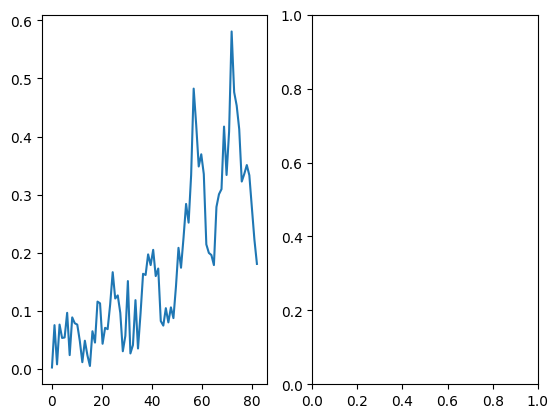

In [ ]:
##Plotting speeds of dFADs vs current data
dFADx = ds2.at[2,"x_speed"]
dFADy =ds2.at[2,"y_speed"]
Mappedx = ds2.at[2,"mapped_u"]
Mappedy = ds2.at[2,"mapped_v"]
times = ds2.at[1,"timelist"]
times =times[:-1]

times = np.linspace(0,82,82)

fig, ax = plt.subplots(1,2)
ax[0].plot(times,dFADx, label = "dFAD")
#ax[0].plot(times,Mappedx, label = "Currents speed (15m)")
ax[0].set_ylabel("x Speed(m/s)")
ax[1].plot(times,dFADy, label = "dFAD")
ax[1].plot(times,Mappedy, label = "Currents speed (15m)")
#ax[1.set_xa]
ax[1].set_ylabel("y Speed(m/s)")

### Setting up adding Time cords to the dataset. 

In [ ]:
##Testing adding hours to a date
data = gpd.read_file(r"Palmyra Data\MI_and_SAT_FAD_positions")
data["Hr_min"]= (data["MinOfTimes"]%1)*24
data["Min_min"] = (data["Hr_min"]%1)*60
data["Hr_min"] = data["Hr_min"]//1
data["Min_min"] = data["Min_min"]//1
print(data["Hr_min"].head(2))
print(data["Min_min"].head(2))
print(data["MinOfDate"].head(2))
time_delta = pd.Timedelta(hours = 4.2)
data["MinOfDate"] = data["MinOfDate"] +time_delta
print(data["MinOfDate"].head(2))

0    16.0
1    12.0
Name: Hr_min, dtype: float64
0    47.0
1    54.0
Name: Min_min, dtype: float64
0   2023-05-04
1   2024-04-07
Name: MinOfDate, dtype: datetime64[ms]
0   2023-05-04 04:12:00
1   2024-04-07 04:12:00
Name: MinOfDate, dtype: datetime64[ns]


In [ ]:
data = gpd.read_file(r"Palmyra Data\MI_and_SAT_FAD_positions")
data  = samplefreq(data)
data , delx_list, dely_list = add_distance_collumns(data)

samplefrequencies = data["SampleFreq"]
startdate = data["MinOfDate"]
minoftimes = data["MinOfTimes"]

timelists = []
for i in range(len(data)):
    interval = samplefrequencies[i]
    temptime = startdate[i]
    hrs = (minoftimes[i]%1)*24
    timelist = []
    timelist.append(temptime)
    numpoints = len(data.at[i,"x_deg"])
    time_delta = pd.Timedelta(hours = interval)
    time_temp = temptime
    for n in range(numpoints):
        time_temp += time_delta
        timelist.append(time_temp)

    timelists.append(timelist)
data["timelist"] = timelists


c:\FATE\functions\funcs.py:171: RuntimeWarning: divide by zero encountered in divide
  heading = np.atan(delx_long/dely_long)


In [ ]:
##Checking too see if it works the way its supposed to
time_array = data.at[0,"timelist"]
print(data.at[0,"MinOfDate"])
print(data.at[0,"MaxOfDate"])
print(len(time_array))
line = data.at[0,"geometry"]
x_km = data.at[0,"x_deg"]
print(len(x_km))
print(sp.get_num_points(line))

2023-05-04 00:00:00
2023-05-19 00:00:00
91
90
91
